In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [ ]:
day = pd.read_csv("day.csv")
hour = pd.read_csv("hour.csv")

print(day.shape, hour.shape)


(731, 16) (17379, 17)


In [ ]:
cols_to_drop = ['instant', 'dteday', 'yr', 'casual', 'registered']

day = day.drop(columns=cols_to_drop)
hour = hour.drop(columns=cols_to_drop)


In [ ]:
print(day.isnull().sum())
print(hour.isnull().sum())

print(day.describe())
print(hour.describe())


season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64
season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64
           season        mnth     holiday     weekday  workingday  weathersit  \
count  731.000000  731.000000  731.000000  731.000000  731.000000  731.000000   
mean     2.496580    6.519836    0.028728    2.997264    0.683995    1.395349   
std      1.110807    3.451913    0.167155    2.004787    0.465233    0.544894   
min      1.000000    1.000000    0.000000    0.000000    0.000000    1.000000   
25%      2.000000    4.000000    0.000000    1.000000    0.000000    1.000000   
50%      3.000000    7.000000    0.000000    3.000000    1.000000    1.000000   
75%      3.000000   10.000000    0.0000

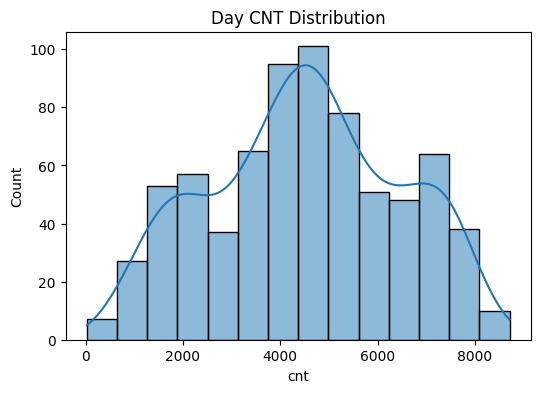

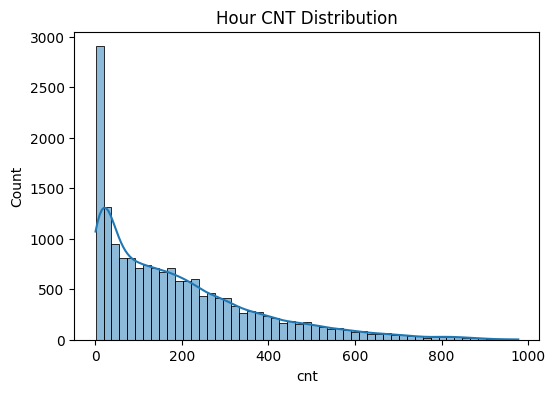

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(day['cnt'], kde=True)
plt.title("Day CNT Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(hour['cnt'], kde=True)
plt.title("Hour CNT Distribution")
plt.show()


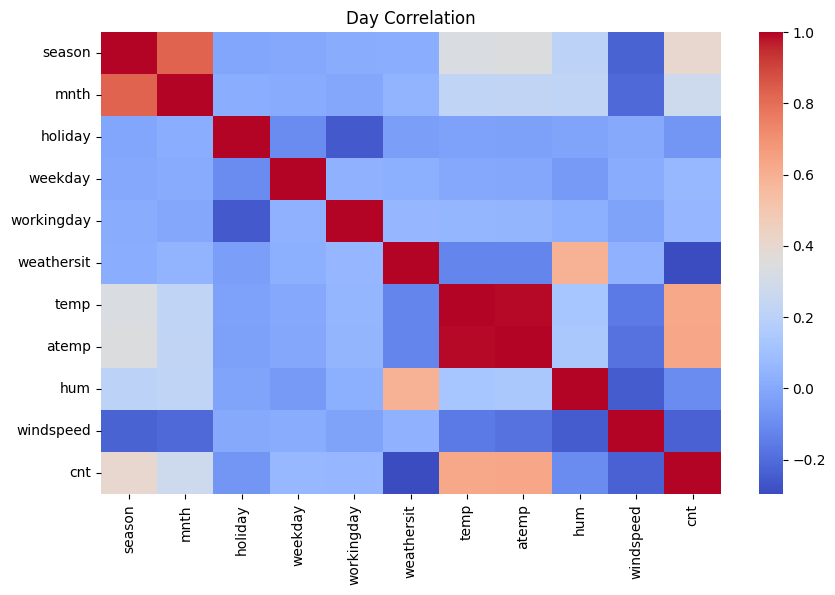

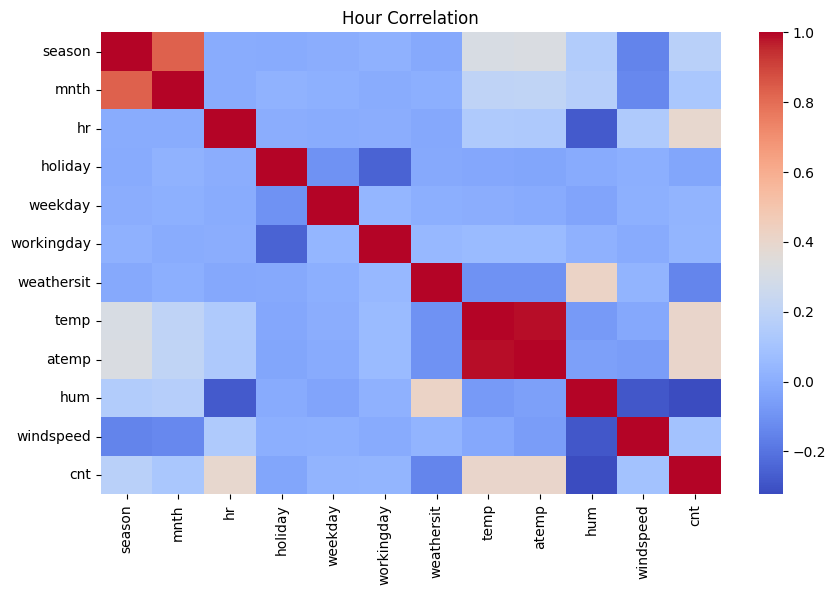

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(day.corr(), cmap='coolwarm')
plt.title("Day Correlation")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(hour.corr(), cmap='coolwarm')
plt.title("Hour Correlation")
plt.show()


In [ ]:
def remove_outliers_iqr(df, target):
    Q1 = df[target].quantile(0.25)
    Q3 = df[target].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[target] >= lower) & (df[target] <= upper)]

day = remove_outliers_iqr(day, 'cnt')
hour = remove_outliers_iqr(hour, 'cnt')


In [ ]:
X_day = day.drop('cnt', axis=1)
y_day = day['cnt']

X_hour = hour.drop('cnt', axis=1)
y_hour = hour['cnt']


In [ ]:
X_day_train, X_day_test, y_day_train, y_day_test = train_test_split(
    X_day, y_day, test_size=0.2, random_state=42)

X_hour_train, X_hour_test, y_hour_train, y_hour_test = train_test_split(
    X_hour, y_hour, test_size=0.2, random_state=42)


In [ ]:
scaler_day = StandardScaler()
X_day_train = scaler_day.fit_transform(X_day_train)
X_day_test = scaler_day.transform(X_day_test)

scaler_hour = StandardScaler()
X_hour_train = scaler_hour.fit_transform(X_hour_train)
X_hour_test = scaler_hour.transform(X_hour_test)


In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    return {
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred),
        "MAE": mean_absolute_error(y_test, test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred))
    }


In [ ]:
from sklearn.svm import SVR

svr_params = {
    'C': [1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}

svr_day = GridSearchCV(SVR(), svr_params, cv=5)
svr_day.fit(X_day_train, y_day_train)

svr_hour = GridSearchCV(SVR(), svr_params, cv=5)
svr_hour.fit(X_hour_train, y_hour_train)


,estimator,SVR()
,param_grid,"{'C': [1, 10, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'rbf'


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gbr_day = GridSearchCV(GradientBoostingRegressor(), gbr_params, cv=5)
gbr_day.fit(X_day_train, y_day_train)

gbr_hour = GridSearchCV(GradientBoostingRegressor(), gbr_params, cv=5)
gbr_hour.fit(X_hour_train, y_hour_train)


,estimator,GradientBoostingRegressor()
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [ ]:
results_day = {
    "SVR": evaluate_model(svr_day.best_estimator_, X_day_train, X_day_test, y_day_train, y_day_test),
    "GBR": evaluate_model(gbr_day.best_estimator_, X_day_train, X_day_test, y_day_train, y_day_test)
}

results_hour = {
    "SVR": evaluate_model(svr_hour.best_estimator_, X_hour_train, X_hour_test, y_hour_train, y_hour_test),
    "GBR": evaluate_model(gbr_hour.best_estimator_, X_hour_train, X_hour_test, y_hour_train, y_hour_test)
}

pd.DataFrame(results_day).T, pd.DataFrame(results_hour).T


(     Train R2   Test R2          MAE         RMSE
 SVR  0.488697  0.501181  1202.074240  1414.285740
 GBR  0.741186  0.610476  1089.072428  1249.777908,
      Train R2   Test R2        MAE       RMSE
 SVR  0.592929  0.581944  63.956568  98.689554
 GBR  0.889830  0.866790  39.205689  55.708622)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

lr_params = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}


In [ ]:
lr_day = GridSearchCV(
    LinearRegression(),
    lr_params,
    cv=5,
    scoring='r2'
)

lr_day.fit(X_day_train, y_day_train)

lr_day_result = evaluate_model(
    lr_day.best_estimator_,
    X_day_train, X_day_test,
    y_day_train, y_day_test
)


In [ ]:
lr_hour = GridSearchCV(
    LinearRegression(),
    lr_params,
    cv=5,
    scoring='r2'
)

lr_hour.fit(X_hour_train, y_hour_train)

lr_hour_result = evaluate_model(
    lr_hour.best_estimator_,
    X_hour_train, X_hour_test,
    y_hour_train, y_hour_test
)


In [ ]:
print("Best LR params (Day):", lr_day.best_params_)
print("Best LR params (Hour):", lr_hour.best_params_)


Best LR params (Day): {'fit_intercept': True, 'positive': False}
Best LR params (Hour): {'fit_intercept': True, 'positive': False}


In [ ]:
from sklearn.linear_model import Ridge

ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}


In [ ]:
ridge_day = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_day.fit(X_day_train, y_day_train)

ridge_day_result = evaluate_model(
    ridge_day.best_estimator_,
    X_day_train, X_day_test,
    y_day_train, y_day_test
)

print("RIDGE – DAY DATASET")
print("Best Params:", ridge_day.best_params_)
pd.DataFrame([ridge_day_result])


RIDGE – DAY DATASET
Best Params: {'alpha': 10}


,Train R2,Test R2,MAE,RMSE
0,0.517546,0.550279,1146.905574,1342.880332


In [ ]:
ridge_hour = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_hour.fit(X_hour_train, y_hour_train)

ridge_hour_result = evaluate_model(
    ridge_hour.best_estimator_,
    X_hour_train, X_hour_test,
    y_hour_train, y_hour_test
)

print("RIDGE – HOUR DATASET")
print("Best Params:", ridge_hour.best_params_)
pd.DataFrame([ridge_hour_result])


RIDGE – HOUR DATASET
Best Params: {'alpha': 10}


,Train R2,Test R2,MAE,RMSE
0,0.362284,0.353322,93.558165,122.743377


In [ ]:
from sklearn.linear_model import Lasso

lasso_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}


In [ ]:
lasso_day = GridSearchCV(
    Lasso(max_iter=5000),
    lasso_params,
    cv=5,
    scoring='r2'
)

lasso_day.fit(X_day_train, y_day_train)

lasso_day_result = evaluate_model(
    lasso_day.best_estimator_,
    X_day_train, X_day_test,
    y_day_train, y_day_test
)

print("LASSO – DAY DATASET")
print("Best Params:", lasso_day.best_params_)
pd.DataFrame([lasso_day_result])


LASSO – DAY DATASET
Best Params: {'alpha': 10}


,Train R2,Test R2,MAE,RMSE
0,0.517172,0.547621,1149.737789,1346.843342


In [ ]:
lasso_hour = GridSearchCV(
    Lasso(max_iter=5000),
    lasso_params,
    cv=5,
    scoring='r2'
)

lasso_hour.fit(X_hour_train, y_hour_train)

lasso_hour_result = evaluate_model(
    lasso_hour.best_estimator_,
    X_hour_train, X_hour_test,
    y_hour_train, y_hour_test
)

print("LASSO – HOUR DATASET")
print("Best Params:", lasso_hour.best_params_)
pd.DataFrame([lasso_hour_result])


LASSO – HOUR DATASET
Best Params: {'alpha': 0.1}


,Train R2,Test R2,MAE,RMSE
0,0.362282,0.353265,93.570556,122.748763


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}


In [ ]:
knn_day = GridSearchCV(
    KNeighborsRegressor(),
    knn_params,
    cv=5,
    scoring='r2'
)

knn_day.fit(X_day_train, y_day_train)

knn_day_result = evaluate_model(
    knn_day.best_estimator_,
    X_day_train, X_day_test,
    y_day_train, y_day_test
)

print("KNN – DAY DATASET")
print("Best Params:", knn_day.best_params_)
pd.DataFrame([knn_day_result])


KNN – DAY DATASET
Best Params: {'n_neighbors': 9, 'weights': 'distance'}


,Train R2,Test R2,MAE,RMSE
0,1.0,0.583945,1128.313069,1291.638408


In [ ]:
knn_hour = GridSearchCV(
    KNeighborsRegressor(),
    knn_params,
    cv=5,
    scoring='r2'
)

knn_hour.fit(X_hour_train, y_hour_train)

knn_hour_result = evaluate_model(
    knn_hour.best_estimator_,
    X_hour_train, X_hour_test,
    y_hour_train, y_hour_test
)

print("KNN – HOUR DATASET")
print("Best Params:", knn_hour.best_params_)
pd.DataFrame([knn_hour_result])


KNN – HOUR DATASET
Best Params: {'n_neighbors': 7, 'weights': 'distance'}


,Train R2,Test R2,MAE,RMSE
0,0.999963,0.643971,63.307409,91.074532


In [ ]:
print("SVR – DAY DATASET")
pd.DataFrame([results_day['SVR']])

print("SVR – HOUR DATASET")
pd.DataFrame([results_hour['SVR']])


SVR – DAY DATASET
SVR – HOUR DATASET


,Train R2,Test R2,MAE,RMSE
0,0.592929,0.581944,63.956568,98.689554


In [ ]:
print("GRADIENT BOOSTING – DAY DATASET")
pd.DataFrame([results_day['GBR']])

print("GRADIENT BOOSTING – HOUR DATASET")
pd.DataFrame([results_hour['GBR']])


GRADIENT BOOSTING – DAY DATASET
GRADIENT BOOSTING – HOUR DATASET


,Train R2,Test R2,MAE,RMSE
0,0.88983,0.86679,39.205689,55.708622


In [ ]:
results_day_all = pd.DataFrame({
    'Linear': lr_day_result,
    'Ridge': ridge_day_result,
    'Lasso': lasso_day_result,
    'KNN': knn_day_result,
    'SVR': results_day['SVR'],
    'GBR': results_day['GBR']
}).T

results_day_all.sort_values(by='Test R2', ascending=False)


,Train R2,Test R2,MAE,RMSE
GBR,0.741186,0.610476,1089.072428,1249.777908
KNN,1.000000,0.583945,1128.313069,1291.638408
Linear,0.517645,0.551863,1143.393718,1340.514122
Ridge,0.517546,0.550279,1146.905574,1342.880332
Lasso,0.517172,0.547621,1149.737789,1346.843342
SVR,0.488697,0.501181,1202.074240,1414.285740


In [ ]:
results_hour_all = pd.DataFrame({
    'Linear': lr_hour_result,
    'Ridge': ridge_hour_result,
    'Lasso': lasso_hour_result,
    'KNN': knn_hour_result,
    'SVR': results_hour['SVR'],
    'GBR': results_hour['GBR']
}).T

results_hour_all.sort_values(by='Test R2', ascending=False)


,Train R2,Test R2,MAE,RMSE
GBR,0.889830,0.866790,39.205689,55.708622
KNN,0.999963,0.643971,63.307409,91.074532
SVR,0.592929,0.581944,63.956568,98.689554
Ridge,0.362284,0.353322,93.558165,122.743377
Lasso,0.362282,0.353265,93.570556,122.748763
Linear,0.362286,0.353154,93.565256,122.759304


In [ ]:
best_day_model = gbr_day.best_estimator_
best_day_model.fit(X_day_train, y_day_train)


,loss,'squared_error'
,learning_rate,0.05
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [ ]:
best_hour_model = gbr_hour.best_estimator_
best_hour_model.fit(X_hour_train, y_hour_train)


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [ ]:
day_features = X_day.columns
hour_features = X_hour.columns

print(day_features)
print(hour_features)


Index(['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit',
       'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')
Index(['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')


In [ ]:
print("DAY FEATURES:", list(X_day.columns))
print("HOUR FEATURES:", list(X_hour.columns))


DAY FEATURES: ['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
HOUR FEATURES: ['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


In [ ]:
# Correct DAY input (10 features)
day_input = pd.DataFrame([[
    1,    # season
    6,    # mnth
    0,    # holiday
    2,    # weekday
    1,    # workingday
    1,    # weathersit
    0.35, # temp
    0.30, # atemp
    0.55, # hum
    0.12  # windspeed
]], columns=X_day.columns)

# Scale
day_input_scaled = scaler_day.transform(day_input)

# Repeat input 6 times
day_input_scaled_6 = np.repeat(day_input_scaled, 6, axis=0)

# Predict
day_predictions = best_day_model.predict(day_input_scaled_6)

print("Next 6 DAY predictions:")
day_predictions


Next 6 DAY predictions:


array([3638.37957937, 3638.37957937, 3638.37957937, 3638.37957937,
       3638.37957937, 3638.37957937])

In [ ]:
# Correct HOUR input (11 features)
hour_input = pd.DataFrame([[
    1,    # season
    6,    # mnth
    12,   # hr
    0,    # holiday
    2,    # weekday
    1,    # workingday
    1,    # weathersit
    0.35, # temp
    0.30, # atemp
    0.55, # hum
    0.12  # windspeed
]], columns=X_hour.columns)

# Scale
hour_input_scaled = scaler_hour.transform(hour_input)

# Repeat input 6 times
hour_input_scaled_6 = np.repeat(hour_input_scaled, 6, axis=0)

# Predict
hour_predictions = best_hour_model.predict(hour_input_scaled_6)

print("Next 6 HOUR predictions:")
hour_predictions


Next 6 HOUR predictions:


array([120.29156633, 120.29156633, 120.29156633, 120.29156633,
       120.29156633, 120.29156633])

In [ ]:
day_predictions_rounded = np.round(day_predictions, 2)
day_predictions_rounded


array([3638.38, 3638.38, 3638.38, 3638.38, 3638.38, 3638.38])

In [ ]:
day_predictions_int = np.round(day_predictions).astype(int)
hour_predictions_int = np.round(hour_predictions).astype(int)

print("DAY:", day_predictions_int)
print("HOUR:", hour_predictions_int)


DAY: [3638 3638 3638 3638 3638 3638]
HOUR: [120 120 120 120 120 120]


In [ ]:
pd.DataFrame({
    "Day_Prediction": np.round(day_predictions, 2),
    "Hour_Prediction": np.round(hour_predictions, 2)
})


,Day_Prediction,Hour_Prediction
0,3638.38,120.29
1,3638.38,120.29
2,3638.38,120.29
3,3638.38,120.29
4,3638.38,120.29
5,3638.38,120.29
